# DenseNet121

In [18]:
# ============================================================
# الخلية 1: المكتبات والإعدادات الأساسية
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ECG CLASSIFICATION USING DENSENET121")
print("Binary | 3-Class | 4-Class")
print("="*80)

ECG CLASSIFICATION USING DENSENET121
Binary | 3-Class | 4-Class


In [19]:
# ============================================================
# الخلية 2: Config - إعدادات المشروع
# ============================================================

class Config:
    DATA_PATH = "/content/clean_data"
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 16
    TARGET_PER_CLASS = 200

    FOLDER_MAPPING = {
        'Normal': ['Normal', 'normal'],
        'Abnormal': ['Abnormal', 'abnormal'],
        'History_MI': ['History_MI', 'history_mi', 'HMI'],
        'Myocardial_Infarction': ['Myocardial_Infarction', 'MI', 'mi', 'Myocardial Infarction']
    }

In [20]:
# ============================================================
# الخلية 3: DataLoader - تحميل البيانات
# ============================================================

class DataLoader:
    def __init__(self, class_names):
        self.class_names = class_names
        self.num_classes = len(class_names)
        self.df = None

    def find_class_folder(self, base_path, class_name):
        for folder_name in Config.FOLDER_MAPPING.get(class_name, [class_name]):
            folder_path = os.path.join(base_path, folder_name)
            if os.path.exists(folder_path) and os.path.isdir(folder_path):
                return folder_path
        return None

    def load_data(self):
        print("\n[1] LOADING DATASET")
        print("="*60)

        data_path = Config.DATA_PATH
        if not os.path.exists(data_path):
            alt_paths = ["/content/drive/MyDrive/clean_data", "/content/clean_data", "/content/data/clean_data"]
            for path in alt_paths:
                if os.path.exists(path):
                    data_path = path
                    break
            else:
                raise FileNotFoundError("Dataset not found!")

        paths, labels = [], []
        for idx, class_name in enumerate(self.class_names):
            folder = self.find_class_folder(data_path, class_name)
            if folder:
                images = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                for img in images:
                    paths.append(os.path.join(folder, img))
                    labels.append(idx)
                print(f"  {class_name}: {len(images)} images")
            else:
                print(f"  {class_name}: folder not found")

        self.df = pd.DataFrame({'path': paths, 'label': labels})
        print(f"\n  Total images: {len(self.df)}")

        for class_name in self.class_names:
            count = len(self.df[self.df['label'] == self.class_names.index(class_name)])
            pct = count / len(self.df) * 100 if len(self.df) > 0 else 0
            print(f"    {class_name}: {count} ({pct:.1f}%)")

        return self.df

In [21]:
# ============================================================
# الخلية 4: ImagePreprocessor - معالجة الصور
# ============================================================

class ImagePreprocessor:
    @staticmethod
    def crop_ecg(image, top_percent=0.20, bottom_percent=0.07):
        h, w = image.shape[:2]
        top = int(h * top_percent)
        bottom = int(h * (1 - bottom_percent))
        return image[top:bottom, :]

    @staticmethod
    def preprocess_image(image_path, target_size=Config.IMG_SIZE):
        img = cv2.imread(image_path)
        if img is None:
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = ImagePreprocessor.crop_ecg(img)
        if len(img.shape) == 3:
            filtered = np.zeros_like(img)
            for i in range(3):
                filtered[:, :, i] = cv2.medianBlur(img[:, :, i], 3)
            img = filtered
        else:
            img = cv2.medianBlur(img, 3)
        img = cv2.resize(img, target_size)
        img = img.astype(np.float32) / 255.0
        return img

In [22]:
# ============================================================
# الخلية 5: DataAugmentor - زيادة البيانات
# ============================================================

class DataAugmentor:
    @staticmethod
    def augment(image):
        if np.random.random() > 0.5:
            image = cv2.flip(image, 1)
        if np.random.random() > 0.5:
            angle = np.random.uniform(-10, 10)
            h, w = image.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        if np.random.random() > 0.5:
            zoom = np.random.uniform(0.9, 1.1)
            h, w = image.shape[:2]
            new_h, new_w = int(h * zoom), int(w * zoom)
            if zoom > 1:
                start_h, start_w = (new_h - h) // 2, (new_w - w) // 2
                cropped = image[start_h:start_h+h, start_w:start_w+w]
                image = cv2.resize(cropped, (w, h))
            else:
                resized = cv2.resize(image, (new_w, new_h))
                pad_h, pad_w = (h - new_h) // 2, (w - new_w) // 2
                image = np.pad(resized, ((pad_h, h - new_h - pad_h), (pad_w, w - new_w - pad_w), (0, 0)), mode='reflect')
        if np.random.random() > 0.5:
            brightness = np.random.uniform(0.85, 1.15)
            image = np.clip(image * brightness, 0, 1)
        return image

In [23]:
# ============================================================
# الخلية 6: DataSplitter - تقسيم البيانات والموازنة
# ============================================================

class DataSplitter:
    def __init__(self, df, class_names):
        self.df = df
        self.class_names = class_names
        self.num_classes = len(class_names)

    def split_data(self):
        train_df, temp_df = train_test_split(self.df, test_size=0.3, stratify=self.df['label'], random_state=42)
        val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)
        self.train_df, self.val_df, self.test_df = train_df, val_df, test_df
        return train_df, val_df, test_df

    def augment_training_data(self):
        print("\n[3] BALANCING TRAINING DATA")
        print("="*60)

        augmented_paths, augmented_labels = [], []
        for class_idx in range(self.num_classes):
            class_df = self.train_df[self.train_df['label'] == class_idx]
            current_count = len(class_df)

            for _, row in class_df.iterrows():
                augmented_paths.append(row['path'])
                augmented_labels.append(class_idx)

            if current_count < Config.TARGET_PER_CLASS:
                needed = Config.TARGET_PER_CLASS - current_count
                print(f"  {self.class_names[class_idx]}: {current_count} -> {Config.TARGET_PER_CLASS} (+{needed})")
                sample_indices = np.random.choice(len(class_df), needed, replace=True)
                for idx in sample_indices:
                    row = class_df.iloc[idx]
                    img = ImagePreprocessor.preprocess_image(row['path'])
                    if img is not None:
                        augmented = DataAugmentor.augment(img.copy())
                        augmented_paths.append(row['path'])
                        augmented_labels.append(class_idx)
            else:
                print(f"  {self.class_names[class_idx]}: {current_count} images")

        self.train_df_aug = pd.DataFrame({'path': augmented_paths, 'label': augmented_labels})

        print("\n  Balanced Distribution:")
        for class_name in self.class_names:
            count = len(self.train_df_aug[self.train_df_aug['label'] == self.class_names.index(class_name)])
            print(f"    {class_name}: {count} images")

        return self.train_df_aug

In [24]:
# ============================================================
# الخلية 7: ECGDataGenerator - مولد البيانات
# ============================================================

class ECGDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, num_classes, shuffle=True, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.num_classes = num_classes
        self.batch_size = Config.BATCH_SIZE
        self.target_size = Config.IMG_SIZE
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.dataframe))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_data = self.dataframe.iloc[batch_indices]
        X, y = [], []
        for _, row in batch_data.iterrows():
            img = ImagePreprocessor.preprocess_image(row['path'])
            if img is not None:
                if self.augment:
                    img = DataAugmentor.augment(img)
                X.append(img)
                y.append(row['label'])
        if len(X) == 0:
            return np.array([]), np.array([])
        X = np.array(X)
        y = tf.keras.utils.to_categorical(y, num_classes=self.num_classes)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [25]:
# ============================================================
# الخلية 8: ModelBuilder - بناء نموذج DenseNet121
# ============================================================

class ModelBuilder:
    @staticmethod
    def build_model(num_classes):
        print("\n[4] BUILDING DENSENET121 MODEL")
        print("="*60)

        base_model = tf.keras.applications.DenseNet121(
            include_top=False,
            weights='imagenet',
            input_shape=(224, 224, 3)
        )
        base_model.trainable = False

        print(f"\n  Base Model Layers: {len(base_model.layers)}")
        print(f"  Output Classes: {num_classes}")

        inputs = keras.Input(shape=(224, 224, 3))
        x = base_model(inputs, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)

        model = keras.Model(inputs=inputs, outputs=outputs)

        total_params = model.count_params()
        trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

        print(f"\n  Total Parameters: {total_params:,}")
        print(f"  Trainable Parameters: {trainable_params:,}")

        return model, base_model

In [26]:
# ============================================================
# الخلية 9: Trainer - التدريب والتقييم
# ============================================================

class Trainer:
    def __init__(self, model, base_model, class_weights, class_names, experiment_name):
        self.model = model
        self.base_model = base_model
        self.class_weights = class_weights
        self.class_names = class_names
        self.experiment_name = experiment_name
        self.history = None
        self.results = None

    def train(self, train_gen, val_gen):
        print("\n[5] TRAINING DENSENET121")
        print("="*60)

        print("\n  Class Weights:")
        for i, class_name in enumerate(self.class_names):
            print(f"    {class_name}: {self.class_weights[i]:.3f}")

        print("\n  Phase 1: Transfer Learning (LR: 1e-3, Epochs: 20)")

        callbacks_1 = [
            callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-7, verbose=1),
            callbacks.ModelCheckpoint(f'{self.experiment_name}_phase1.keras',
                                     monitor='val_accuracy', save_best_only=True, verbose=1)
        ]

        self.model.compile(
            loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            metrics=['accuracy']
        )

        history1 = self.model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=20,
            callbacks=callbacks_1,
            class_weight=self.class_weights,
            verbose=1
        )

        print("\n  Phase 2: Fine-Tuning (LR: 1e-5, Epochs: 10)")

        self.base_model.trainable = True
        for layer in self.base_model.layers[:200]:
            layer.trainable = False

        callbacks_2 = [
            callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
            callbacks.ModelCheckpoint(f'{self.experiment_name}_final.keras',
                                     monitor='val_accuracy', save_best_only=True, verbose=1)
        ]

        self.model.compile(
            loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(learning_rate=1e-5),
            metrics=['accuracy']
        )

        history2 = self.model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=10,
            callbacks=callbacks_2,
            class_weight=self.class_weights,
            verbose=1
        )

        self.history = {}
        all_keys = set(history1.history.keys()) | set(history2.history.keys())
        for key in all_keys:
            combined = []
            if key in history1.history:
                combined.extend(history1.history[key])
            if key in history2.history:
                combined.extend(history2.history[key])
            self.history[key] = combined

        return self.history

    def evaluate(self, test_gen):
        print("\n[6] EVALUATING MODEL")
        print("="*60)

        try:
            self.model.load_weights(f'{self.experiment_name}_final.keras')
            print("  Loaded fine-tuned model")
        except:
            self.model.load_weights(f'{self.experiment_name}_phase1.keras')
            print("  Loaded phase 1 model")

        loss, accuracy = self.model.evaluate(test_gen, verbose=0)
        print(f"\n  Test Accuracy: {accuracy*100:.2f}%")
        print(f"  Test Loss: {loss:.4f}")

        y_pred_probs = self.model.predict(test_gen, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)

        y_true = []
        for i in range(len(test_gen)):
            _, y_batch = test_gen[i]
            y_true.extend(np.argmax(y_batch, axis=1))
        y_true = np.array(y_true)

        cm = confusion_matrix(y_true, y_pred)
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(len(self.class_names)):
            fpr[i], tpr[i], _ = roc_curve(y_true == i, y_pred_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        self.results = {
            'loss': loss,
            'accuracy': accuracy,
            'y_true': y_true,
            'y_pred': y_pred,
            'confusion_matrix': cm,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc
        }
        return self.results

In [27]:
# ============================================================
# الخلية 10: OverfittingAnalyzer - تحليل فرط التخصص
# ============================================================

class OverfittingAnalyzer:
    @staticmethod
    def analyze(history):
        if 'accuracy' not in history or 'val_accuracy' not in history:
            return {'level': 'UNKNOWN', 'gap': 0}
        train_acc = history['accuracy']
        val_acc = history['val_accuracy']
        acc_gap = np.array(train_acc) - np.array(val_acc)
        final_gap = acc_gap[-1] if len(acc_gap) > 0 else 0

        if final_gap > 0.15:
            level, recommendation = "HIGH", "Increase regularization or augmentation"
        elif final_gap > 0.08:
            level, recommendation = "MEDIUM", "Monitor closely"
        else:
            level, recommendation = "LOW", "Model generalizes well"

        return {
            'level': level,
            'final_gap': final_gap,
            'train_acc': train_acc[-1] if len(train_acc) > 0 else 0,
            'val_acc': val_acc[-1] if len(val_acc) > 0 else 0,
            'recommendation': recommendation
        }

In [28]:
# ============================================================
# الخلية 11: Visualizer - الرسوم البيانية
# ============================================================

class Visualizer:
    @staticmethod
    def plot_class_distribution(train_df, val_df, test_df, class_names, title_prefix=""):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        colors = ['#4CAF50', '#2196F3', '#FF5722', '#FFC107']

        for idx, (df, title, ax) in enumerate(zip([train_df, val_df, test_df],
                                                   ['Training', 'Validation', 'Test'], axes)):
            counts = df['label'].value_counts()
            class_names_used = [class_names[i] for i in counts.index]
            bars = ax.bar(class_names_used, counts.values, color=colors[:len(class_names_used)])
            ax.set_title(f'{title} Set', fontsize=12, fontweight='bold')
            ax.set_xlabel('Class')
            ax.set_ylabel('Number of Images')
            for bar, count in zip(bars, counts.values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{count}', ha='center', va='bottom')

        plt.suptitle(f'{title_prefix} Class Distribution', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_history(history, title_prefix=""):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        axes[0, 0].plot(history['accuracy'], label='Train', linewidth=2)
        axes[0, 0].plot(history['val_accuracy'], label='Validation', linewidth=2)
        axes[0, 0].axvline(x=20, color='red', linestyle='--', label='Fine-tuning', alpha=0.7)
        axes[0, 0].set_title(f'{title_prefix} Model Accuracy', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].plot(history['loss'], label='Train', linewidth=2)
        axes[0, 1].plot(history['val_loss'], label='Validation', linewidth=2)
        axes[0, 1].axvline(x=20, color='red', linestyle='--', label='Fine-tuning', alpha=0.7)
        axes[0, 1].set_title(f'{title_prefix} Model Loss', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        train_acc = np.array(history['accuracy'])
        val_acc = np.array(history['val_accuracy'])
        acc_gap = train_acc - val_acc
        axes[0, 2].plot(acc_gap, color='blue', linewidth=2)
        axes[0, 2].axhline(y=0.08, color='orange', linestyle='--', label='Medium')
        axes[0, 2].axhline(y=0.15, color='red', linestyle='--', label='High')
        axes[0, 2].fill_between(range(len(acc_gap)), 0, acc_gap, alpha=0.3)
        axes[0, 2].set_title(f'Accuracy Gap (Final: {acc_gap[-1]:.4f})', fontsize=14, fontweight='bold')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Gap')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)

        if 'learning_rate' in history:
            axes[1, 0].plot(history['learning_rate'], color='purple', linewidth=2)
            axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Learning Rate')
            axes[1, 0].set_yscale('log')
            axes[1, 0].grid(True, alpha=0.3)
        else:
            axes[1, 0].axis('off')

        axes[1, 1].axis('off')

        axes[1, 2].axis('off')
        axes[1, 2].set_title('Training Summary', fontsize=14, fontweight='bold')
        metrics = [
            ('Train Acc', f"{train_acc[-1]*100:.1f}%"),
            ('Val Acc', f"{val_acc[-1]*100:.1f}%"),
            ('Gap', f"{acc_gap[-1]:.4f}"),
        ]
        y_pos = 0.8
        for metric, value in metrics:
            axes[1, 2].text(0.1, y_pos, f'{metric}:', fontsize=12, fontweight='bold')
            axes[1, 2].text(0.5, y_pos, value, fontsize=12)
            y_pos -= 0.15

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_confusion_matrix(cm, class_names, title_prefix=""):
        plt.figure(figsize=(10, 9))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=class_names, yticklabels=class_names)
        plt.title(f'{title_prefix} Confusion Matrix', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_roc_curves(fpr, tpr, roc_auc, class_names, title_prefix=""):
        plt.figure(figsize=(10, 8))
        for i, class_name in enumerate(class_names):
            plt.plot(fpr[i], tpr[i], label=f'{class_name} (AUC = {roc_auc[i]:.3f})', linewidth=2)
        plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{title_prefix} ROC Curves', fontsize=14, fontweight='bold')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [29]:
# ============================================================
# الخلية 12: ExperimentRunner - تشغيل التجارب
# ============================================================

class ExperimentRunner:
    def __init__(self, class_names, experiment_name, output_prefix):
        self.class_names = class_names
        self.num_classes = len(class_names)
        self.experiment_name = experiment_name
        self.output_prefix = output_prefix
        self.results = None
        self.model = None

    def run(self):
        print("\n" + "="*80)
        print(f"{self.experiment_name}")
        print(f"Classes: {', '.join(self.class_names)}")
        print("="*80)

        loader = DataLoader(self.class_names)
        df = loader.load_data()

        splitter = DataSplitter(df, self.class_names)
        train_df, val_df, test_df = splitter.split_data()
        train_df_aug = splitter.augment_training_data()

        Visualizer.plot_class_distribution(train_df_aug, val_df, test_df, self.class_names, self.experiment_name)

        train_gen = ECGDataGenerator(train_df_aug, self.num_classes, shuffle=True, augment=True)
        val_gen = ECGDataGenerator(val_df, self.num_classes, shuffle=False, augment=False)
        test_gen = ECGDataGenerator(test_df, self.num_classes, shuffle=False, augment=False)

        y_train = train_df_aug['label'].values
        if len(np.unique(y_train)) < 2:
            class_weights = {i: 1.0 for i in range(self.num_classes)}
        else:
            class_weights_list = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
            class_weights = {i: w for i, w in enumerate(class_weights_list)}

        model, base_model = ModelBuilder.build_model(self.num_classes)

        trainer = Trainer(model, base_model, class_weights, self.class_names, self.experiment_name)
        history = trainer.train(train_gen, val_gen)
        results = trainer.evaluate(test_gen)

        Visualizer.plot_history(history, self.experiment_name)
        Visualizer.plot_confusion_matrix(results['confusion_matrix'], self.class_names, self.experiment_name)
        Visualizer.plot_roc_curves(results['fpr'], results['tpr'], results['roc_auc'], self.class_names, self.experiment_name)

        overfitting = OverfittingAnalyzer.analyze(history)

        self._print_summary(results, overfitting)

        model.save(f'{self.output_prefix}_model.keras')

        self.results = results
        self.model = model
        return results, model, history

    def _print_summary(self, results, overfitting):
        print("\n" + "="*80)
        print(f"{self.experiment_name} - FINAL SUMMARY")
        print("="*80)

        cm = results['confusion_matrix']
        acc = results['accuracy'] * 100
        f1_macro = f1_score(results['y_true'], results['y_pred'], average='macro')
        f1_weighted = f1_score(results['y_true'], results['y_pred'], average='weighted')

        print(f"Test Accuracy: {acc:.2f}%")
        print(f"Macro F1: {f1_macro:.3f}")
        print(f"Weighted F1: {f1_weighted:.3f}")

        print("\nPer-Class Accuracy:")
        for i, class_name in enumerate(self.class_names):
            if np.sum(cm[i, :]) > 0:
                print(f"  {class_name}: {cm[i, i] / np.sum(cm[i, :]) * 100:.2f}%")

        print("\nROC-AUC Scores:")
        for i, class_name in enumerate(self.class_names):
            print(f"  {class_name}: {results['roc_auc'][i]:.3f}")

        print(f"\nOverfitting Level: {overfitting['level']}")
        print(f"Accuracy Gap: {overfitting['final_gap']:.4f}")
        print("="*80)


STARTING EXPERIMENT 1: BINARY CLASSIFICATION
Normal vs Abnormal

Binary Classification
Classes: Normal, Abnormal

[1] LOADING DATASET
  Normal: 142 images
  Abnormal: 233 images

  Total images: 375
    Normal: 142 (37.9%)
    Abnormal: 233 (62.1%)

[3] BALANCING TRAINING DATA
  Normal: 99 -> 200 (+101)
  Abnormal: 163 -> 200 (+37)

  Balanced Distribution:
    Normal: 200 images
    Abnormal: 200 images


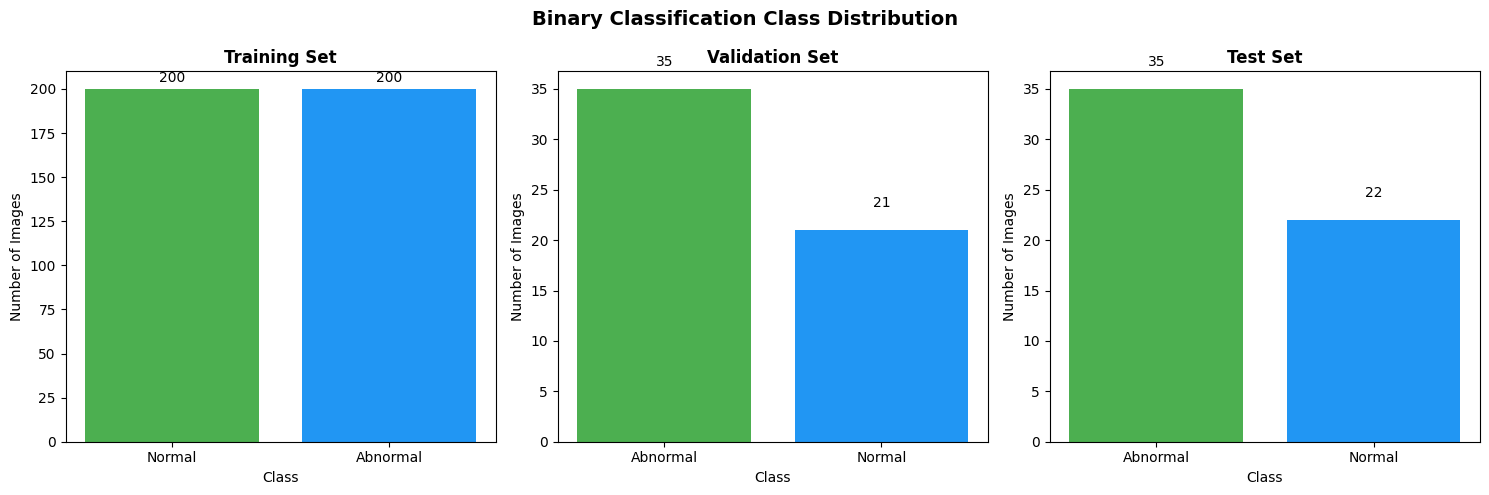


[4] BUILDING DENSENET121 MODEL
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  Base Model Layers: 427
  Output Classes: 2

  Total Parameters: 7,177,858
  Trainable Parameters: 139,970

[5] TRAINING DENSENET121

  Class Weights:
    Normal: 1.000
    Abnormal: 1.000

  Phase 1: Transfer Learning (LR: 1e-3, Epochs: 20)
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5377 - loss: 1.1395
Epoch 1: val_accuracy improved from None to 0.41071, saving model to Binary Classification_phase1.keras

Epoch 1: finished saving model to Binary Classification_phase1.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - accuracy: 0.6000 - loss: 0.9321 - val_accuracy: 0.4107 - val_loss: 1.3007 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7397 - loss: 0.6140
Epoch 2: val_accuracy improved from 0.41071 to 0.83929, saving model to Binary Classification_phase1.keras

Epoch 2: finished saving model to Binary Classification_phase1.keras
25/25 ━━━━━━━━━━

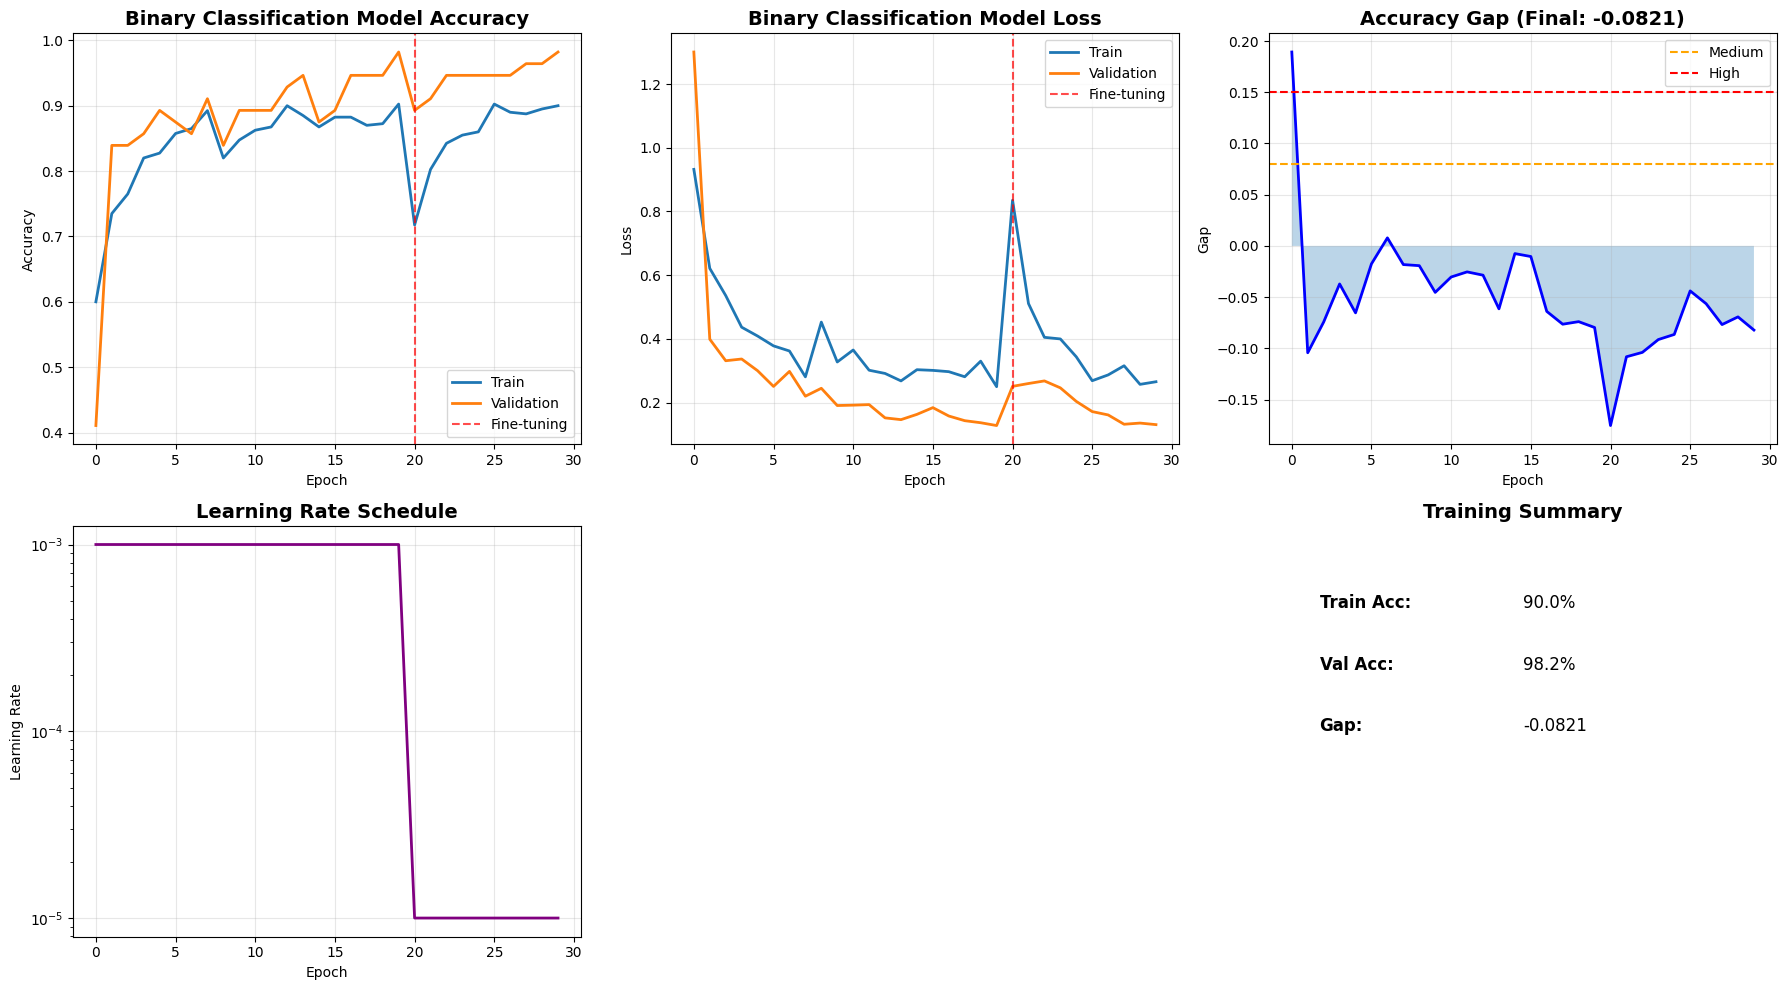

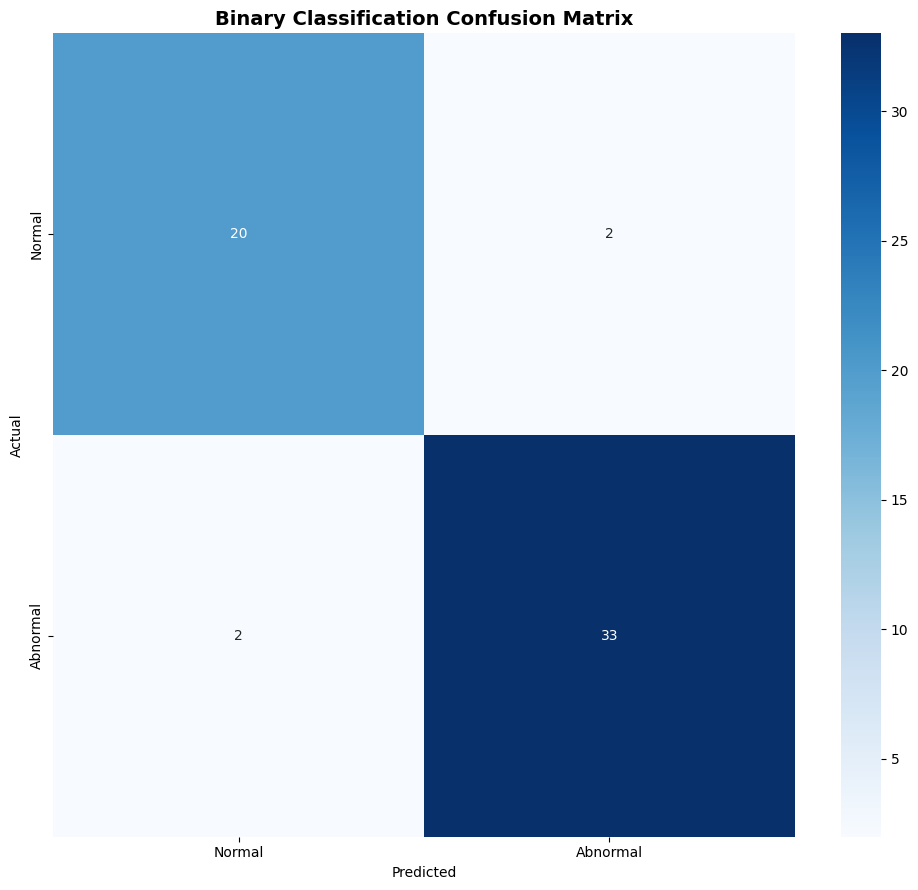

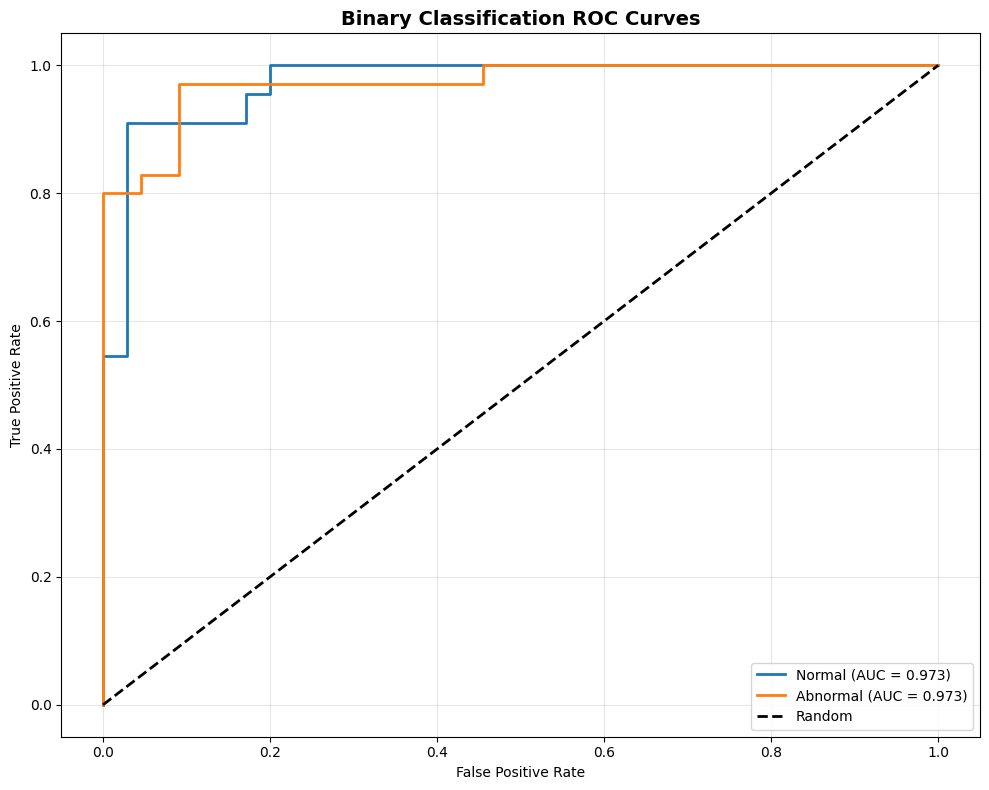


Binary Classification - FINAL SUMMARY
Test Accuracy: 92.98%
Macro F1: 0.926
Weighted F1: 0.930

Per-Class Accuracy:
  Normal: 90.91%
  Abnormal: 94.29%

ROC-AUC Scores:
  Normal: 0.973
  Abnormal: 0.973

Overfitting Level: LOW
Accuracy Gap: -0.0821


In [30]:
# ============================================================
# الخلية 13: تشغيل التجربة 1 - Binary Classification
# ============================================================

print("\n" + "="*80)
print("STARTING EXPERIMENT 1: BINARY CLASSIFICATION")
print("Normal vs Abnormal")
print("="*80)

exp1 = ExperimentRunner(
    class_names=['Normal', 'Abnormal'],
    experiment_name="Binary Classification",
    output_prefix="densenet_binary"
)
results1, model1, history1 = exp1.run()


STARTING EXPERIMENT 2: 3-CLASS CLASSIFICATION
Normal vs Abnormal vs History_MI

3-Class Classification
Classes: Normal, Abnormal, History_MI

[1] LOADING DATASET
  Normal: 142 images
  Abnormal: 233 images
  History_MI: 86 images

  Total images: 461
    Normal: 142 (30.8%)
    Abnormal: 233 (50.5%)
    History_MI: 86 (18.7%)

[3] BALANCING TRAINING DATA
  Normal: 99 -> 200 (+101)
  Abnormal: 163 -> 200 (+37)
  History_MI: 60 -> 200 (+140)

  Balanced Distribution:
    Normal: 200 images
    Abnormal: 200 images
    History_MI: 200 images


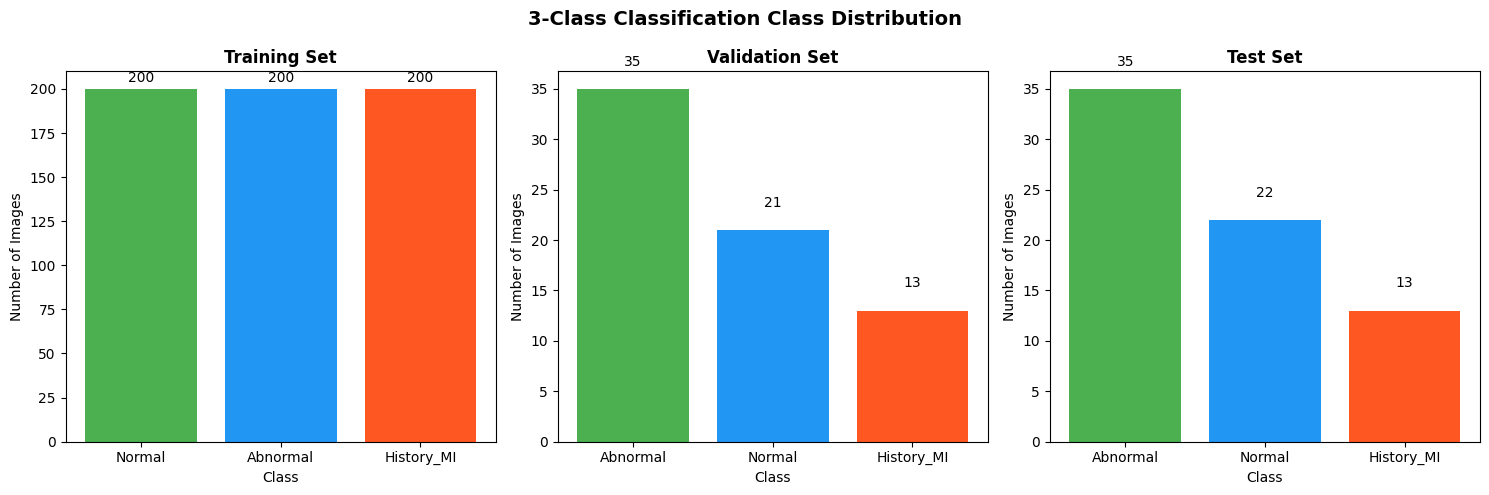


[4] BUILDING DENSENET121 MODEL

  Base Model Layers: 427
  Output Classes: 3

  Total Parameters: 7,177,923
  Trainable Parameters: 140,035

[5] TRAINING DENSENET121

  Class Weights:
    Normal: 1.000
    Abnormal: 1.000
    History_MI: 1.000

  Phase 1: Transfer Learning (LR: 1e-3, Epochs: 20)
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3963 - loss: 1.5594
Epoch 1: val_accuracy improved from None to 0.20290, saving model to 3-Class Classification_phase1.keras

Epoch 1: finished saving model to 3-Class Classification_phase1.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.4083 - loss: 1.5085 - val_accuracy: 0.2029 - val_loss: 1.8153 - learning_rate: 0.0010
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4883 - loss: 1.2693
Epoch 2: val_accuracy did not improve from 0.20290
38/38 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.4900 - loss: 1.2298 - val_accuracy: 0.2029 - val_loss: 1.5605 - learning_rate: 0.0010
Epoch 3/20
38/38 ━━━━━━━━━━━━

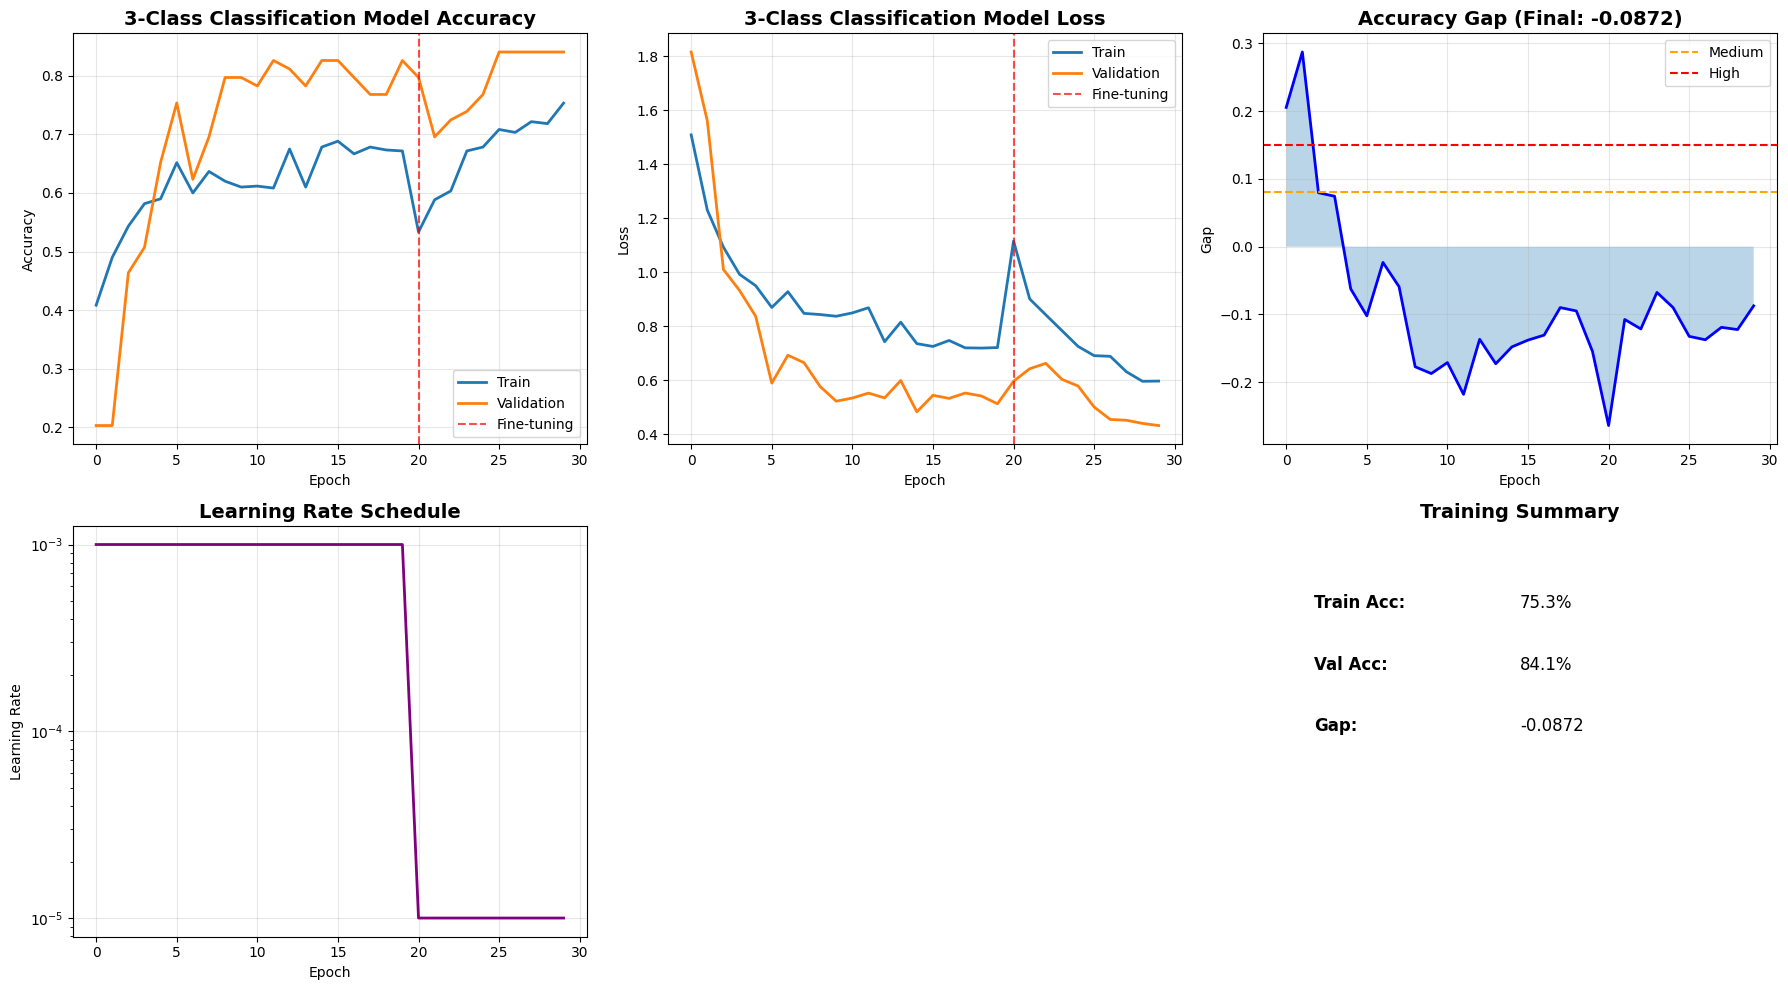

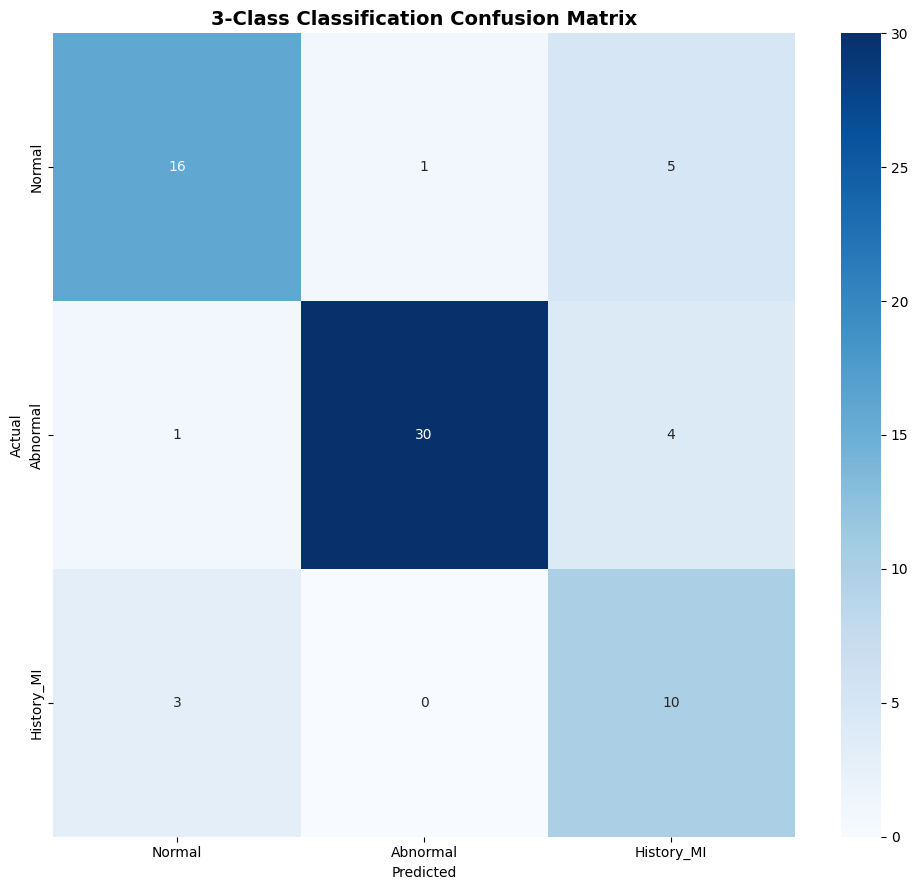

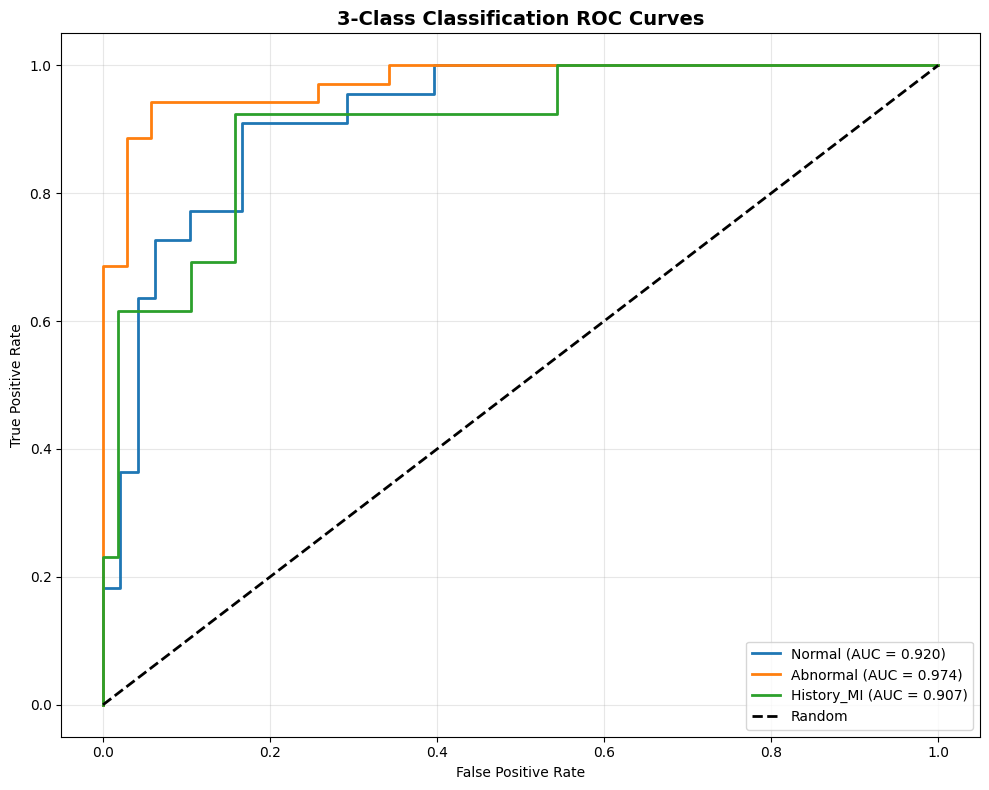


3-Class Classification - FINAL SUMMARY
Test Accuracy: 80.00%
Macro F1: 0.765
Weighted F1: 0.810

Per-Class Accuracy:
  Normal: 72.73%
  Abnormal: 85.71%
  History_MI: 76.92%

ROC-AUC Scores:
  Normal: 0.920
  Abnormal: 0.974
  History_MI: 0.907

Overfitting Level: LOW
Accuracy Gap: -0.0872


In [31]:
# ============================================================
# الخلية 14: تشغيل التجربة 2 - 3-Class Classification
# ============================================================

print("\n" + "="*80)
print("STARTING EXPERIMENT 2: 3-CLASS CLASSIFICATION")
print("Normal vs Abnormal vs History_MI")
print("="*80)

exp2 = ExperimentRunner(
    class_names=['Normal', 'Abnormal', 'History_MI'],
    experiment_name="3-Class Classification",
    output_prefix="densenet_3class"
)
results2, model2, history2 = exp2.run()


STARTING EXPERIMENT 3: 4-CLASS CLASSIFICATION
Normal vs Abnormal vs History_MI vs Myocardial_Infarction

4-Class Classification
Classes: Normal, Abnormal, History_MI, Myocardial_Infarction

[1] LOADING DATASET
  Normal: 142 images
  Abnormal: 233 images
  History_MI: 86 images
  Myocardial_Infarction: 30 images

  Total images: 491
    Normal: 142 (28.9%)
    Abnormal: 233 (47.5%)
    History_MI: 86 (17.5%)
    Myocardial_Infarction: 30 (6.1%)

[3] BALANCING TRAINING DATA
  Normal: 99 -> 200 (+101)
  Abnormal: 163 -> 200 (+37)
  History_MI: 60 -> 200 (+140)
  Myocardial_Infarction: 21 -> 200 (+179)

  Balanced Distribution:
    Normal: 200 images
    Abnormal: 200 images
    History_MI: 200 images
    Myocardial_Infarction: 200 images


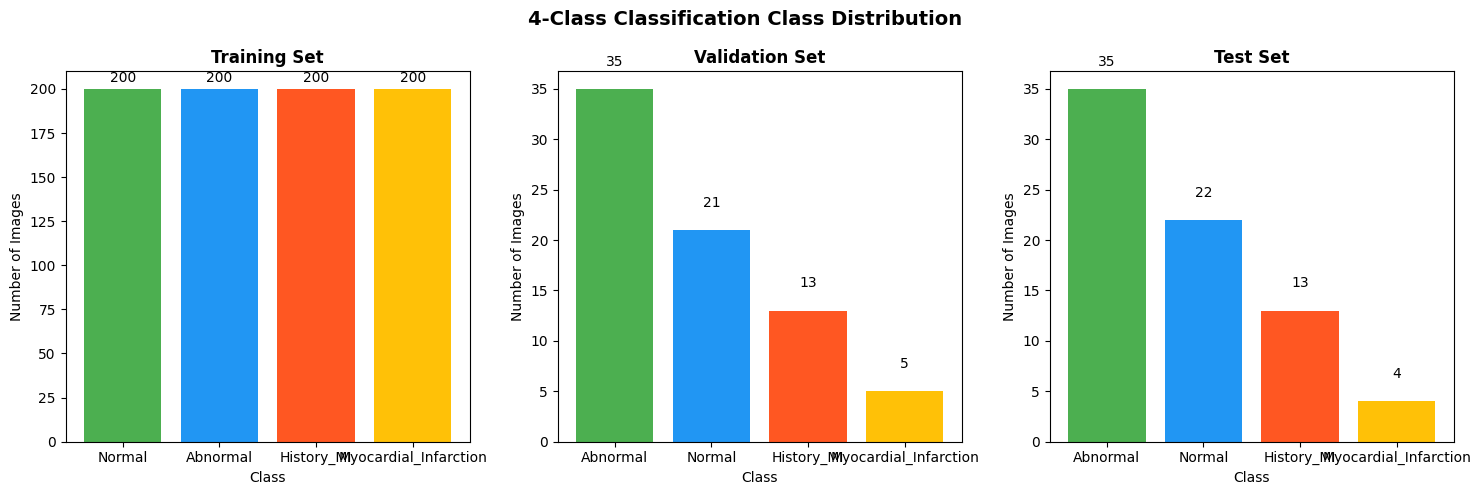


[4] BUILDING DENSENET121 MODEL

  Base Model Layers: 427
  Output Classes: 4

  Total Parameters: 7,177,988
  Trainable Parameters: 140,100

[5] TRAINING DENSENET121

  Class Weights:
    Normal: 1.000
    Abnormal: 1.000
    History_MI: 1.000
    Myocardial_Infarction: 1.000

  Phase 1: Transfer Learning (LR: 1e-3, Epochs: 20)
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2896 - loss: 1.9465
Epoch 1: val_accuracy improved from None to 0.22973, saving model to 4-Class Classification_phase1.keras

Epoch 1: finished saving model to 4-Class Classification_phase1.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 205s 4s/step - accuracy: 0.3325 - loss: 1.7769 - val_accuracy: 0.2297 - val_loss: 1.3056 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4149 - loss: 1.5462
Epoch 2: val_accuracy improved from 0.22973 to 0.43243, saving model to 4-Class Classification_phase1.keras

Epoch 2: finished saving model to 4-Class Classification_phase1.keras
50/50 ━━

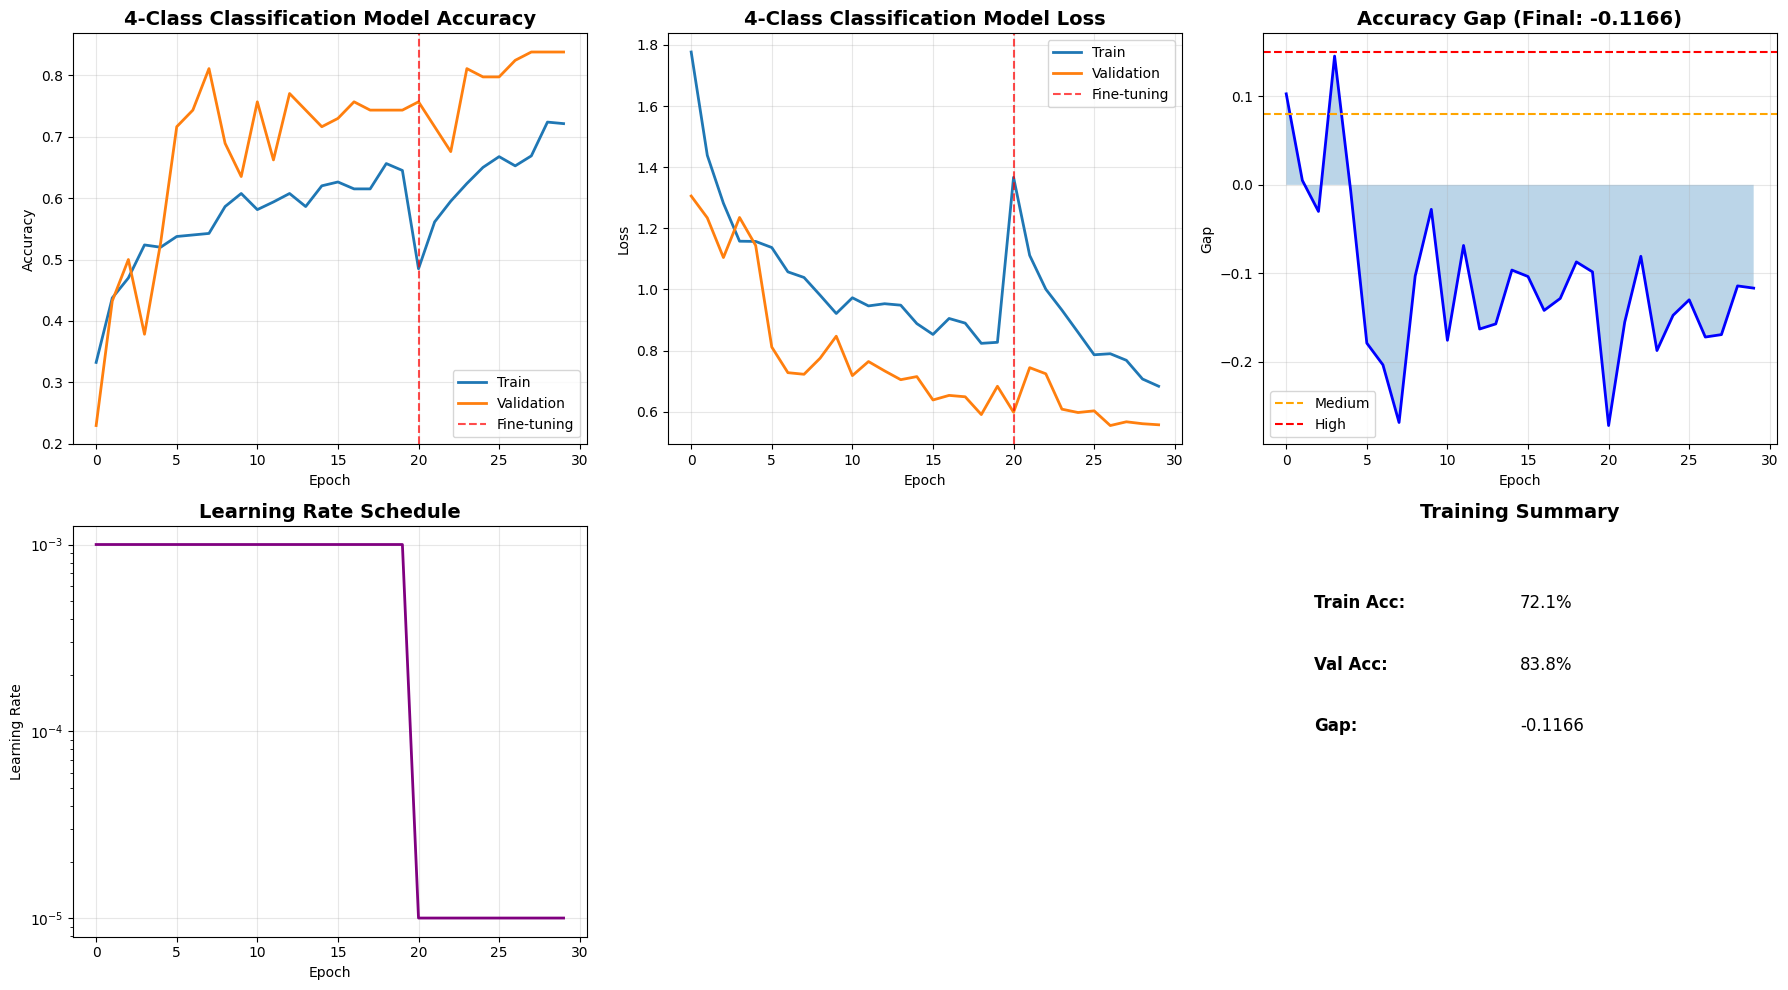

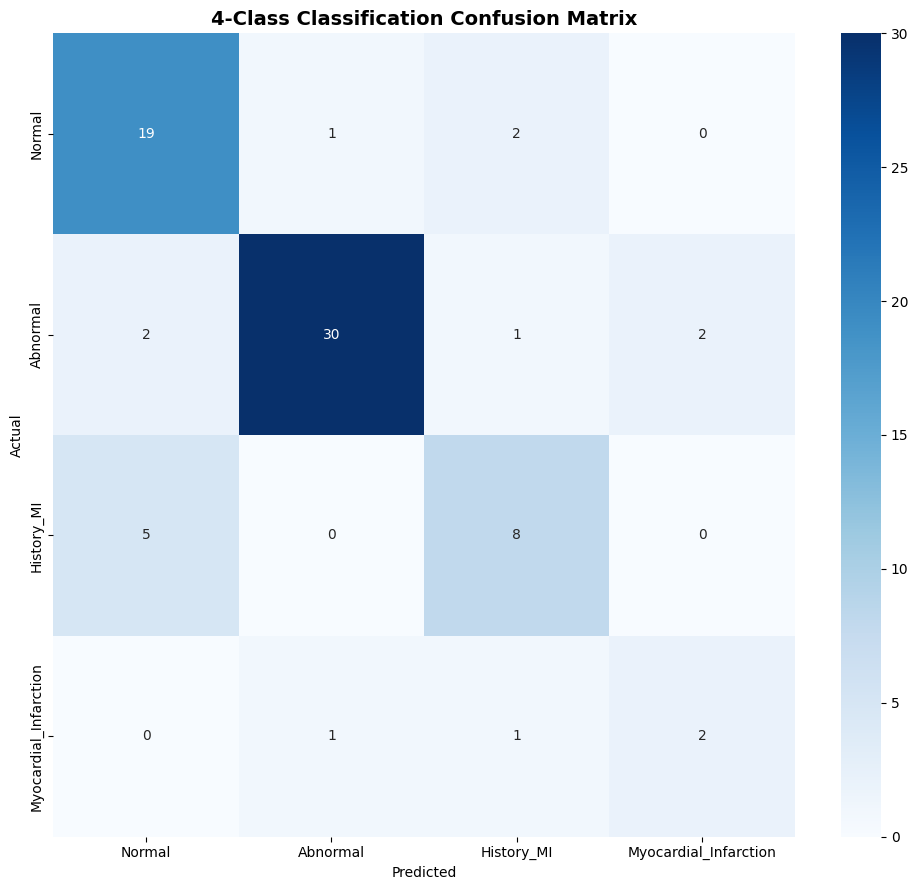

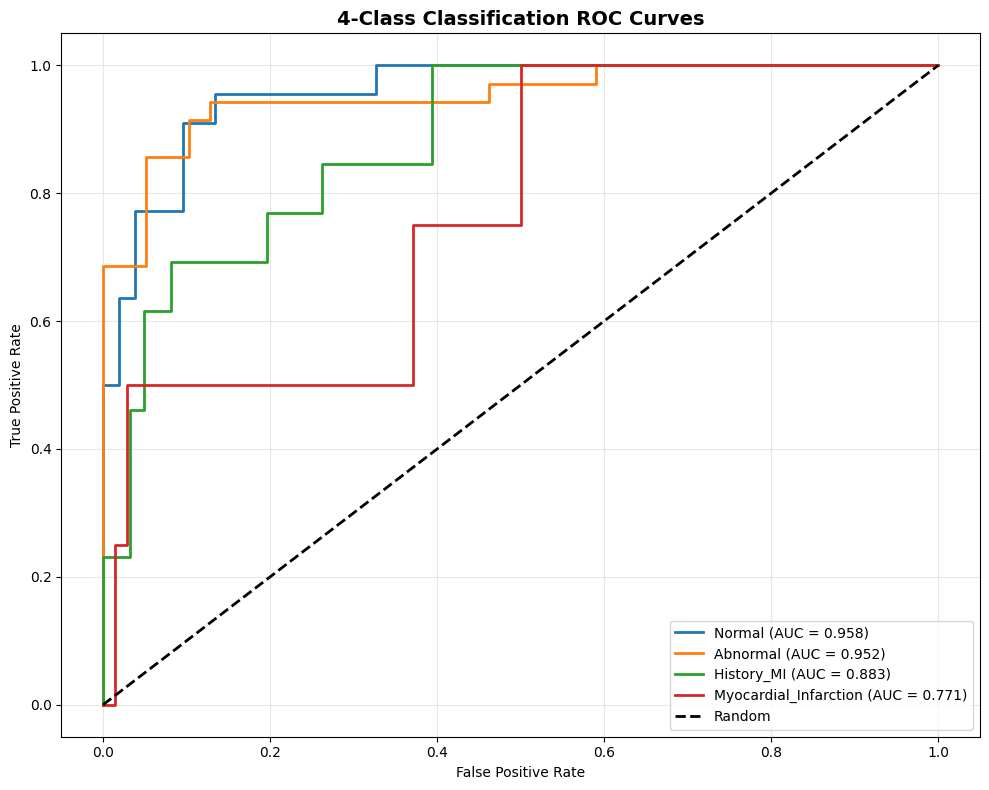


4-Class Classification - FINAL SUMMARY
Test Accuracy: 79.73%
Macro F1: 0.707
Weighted F1: 0.798

Per-Class Accuracy:
  Normal: 86.36%
  Abnormal: 85.71%
  History_MI: 61.54%
  Myocardial_Infarction: 50.00%

ROC-AUC Scores:
  Normal: 0.958
  Abnormal: 0.952
  History_MI: 0.883
  Myocardial_Infarction: 0.771

Overfitting Level: LOW
Accuracy Gap: -0.1166


In [32]:
# ============================================================
# الخلية 15: تشغيل التجربة 3 - 4-Class Classification
# ============================================================

print("\n" + "="*80)
print("STARTING EXPERIMENT 3: 4-CLASS CLASSIFICATION")
print("Normal vs Abnormal vs History_MI vs Myocardial_Infarction")
print("="*80)

exp3 = ExperimentRunner(
    class_names=['Normal', 'Abnormal', 'History_MI', 'Myocardial_Infarction'],
    experiment_name="4-Class Classification",
    output_prefix="densenet_4class"
)
results3, model3, history3 = exp3.run()


COMPARISON SUMMARY - DENSENET121 EXPERIMENTS

  Comparison Table:
Experiment Classes  Test Accuracy (%)  Test Loss Overfitting Level
    Binary       2          92.982459   0.246745               LOW
   3-Class       3          80.000001   0.529112               LOW
   4-Class       4          79.729730   0.651378               LOW


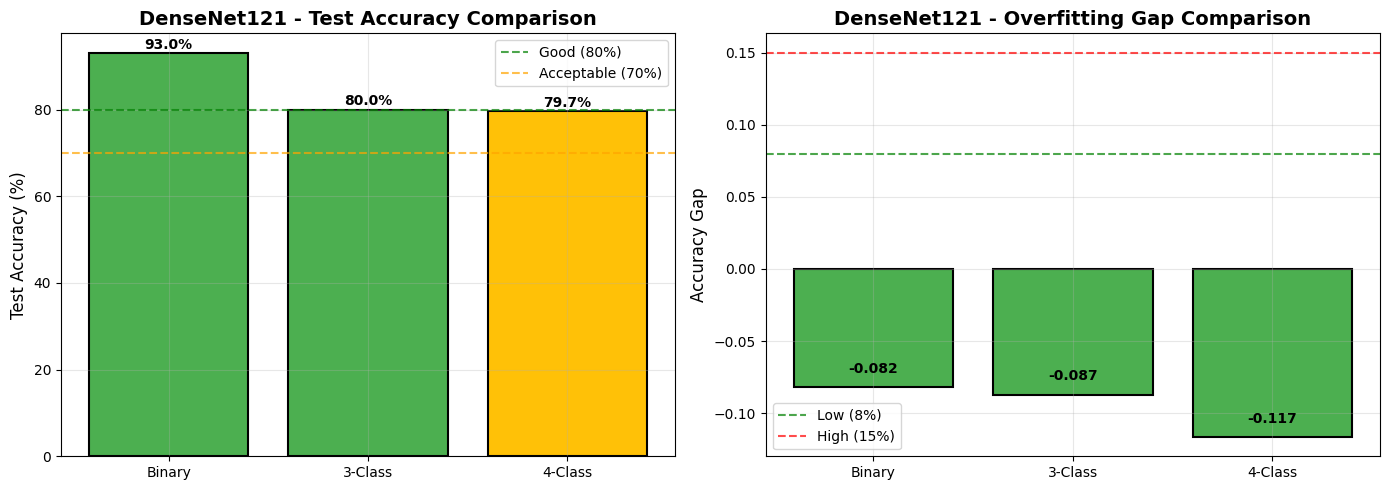


ALL EXPERIMENTS COMPLETED SUCCESSFULLY!
Models saved:
  - densenet_binary_model.keras
  - densenet_3class_model.keras
  - densenet_4class_model.keras


In [33]:
# ============================================================
# الخلية 16: جدول المقارنة النهائي
# ============================================================

print("\n" + "="*80)
print("COMPARISON SUMMARY - DENSENET121 EXPERIMENTS")
print("="*80)

comparison_data = {
    'Experiment': ['Binary', '3-Class', '4-Class'],
    'Classes': ['2', '3', '4'],
    'Test Accuracy (%)': [
        results1['accuracy'] * 100,
        results2['accuracy'] * 100,
        results3['accuracy'] * 100
    ],
    'Test Loss': [
        results1['loss'],
        results2['loss'],
        results3['loss']
    ],
    'Overfitting Level': [
        OverfittingAnalyzer.analyze(history1)['level'],
        OverfittingAnalyzer.analyze(history2)['level'],
        OverfittingAnalyzer.analyze(history3)['level']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n  Comparison Table:")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

experiments = ['Binary', '3-Class', '4-Class']
accuracies = [results1['accuracy']*100, results2['accuracy']*100, results3['accuracy']*100]
colors = ['#4CAF50' if acc > 80 else '#FFC107' if acc > 70 else '#FF6B6B' for acc in accuracies]

axes[0].bar(experiments, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=80, color='green', linestyle='--', label='Good (80%)', alpha=0.7)
axes[0].axhline(y=70, color='orange', linestyle='--', label='Acceptable (70%)', alpha=0.7)
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('DenseNet121 - Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

gaps = [
    OverfittingAnalyzer.analyze(history1)['final_gap'],
    OverfittingAnalyzer.analyze(history2)['final_gap'],
    OverfittingAnalyzer.analyze(history3)['final_gap']
]
colors_gap = ['#4CAF50' if gap < 0.08 else '#FFC107' if gap < 0.15 else '#FF6B6B' for gap in gaps]

axes[1].bar(experiments, gaps, color=colors_gap, edgecolor='black', linewidth=1.5)
axes[1].axhline(y=0.08, color='green', linestyle='--', label='Low (8%)', alpha=0.7)
axes[1].axhline(y=0.15, color='red', linestyle='--', label='High (15%)', alpha=0.7)
axes[1].set_ylabel('Accuracy Gap', fontsize=12)
axes[1].set_title('DenseNet121 - Overfitting Gap Comparison', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(gaps):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ALL EXPERIMENTS COMPLETED SUCCESSFULLY!")
print("Models saved:")
print("  - densenet_binary_model.keras")
print("  - densenet_3class_model.keras")
print("  - densenet_4class_model.keras")
print("="*80)